# Chapter 7.19: Graph Neural Networks (GNNs): Learning on Relational Data

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/07-Machine-Learning/19_Graph_Neural_Networks.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=07-Machine-Learning/19_Graph_Neural_Networks.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

---

### Table of Contents

1.  [**Why GNNs? The Importance of Network Data in Economics**](#1-why-gnns-the-importance-of-network-data-in-economics)
2.  [**The Message Passing Mechanism**](#2-the-message-passing-mechanism)
3.  [**Case Study: Supply Chain Shock Propagation**](#3-case-study-supply-chain-shock-propagation)
4.  [**Exercises**](#4-exercises)
5.  [**Summary and Key Takeaways**](#5-summary-and-key-takeaways)


## The Lens: Learning on Network-Structured Data
**What problem are we solving?**
Economic agents are connected: firms in supply chains, banks in interbank networks, countries in trade webs. Standard ML treats observations as independent. **Graph Neural Networks (GNNs)** learn directly on graph-structured data, capturing how a node's features depend on its neighbors.

**Why this method?**
GNNs enable predicting firm defaults from supply-chain structure, detecting financial fraud from transaction graphs, and modeling contagion in interconnected systems.



**Economic question.** In *Chapter 7.19: Graph Neural Networks (GNNs): Learning on Relational Data*, what must remain economically invariant when the computational representation changes? For economists, predictive performance is useful but not sufficient. The model must be evaluated against the decision or forecasting problem, the information set available at prediction time, and the cost of distribution shift or leakage. Ask what inductive bias the method introduces, how tuning choices are validated out of sample, and which errors matter economically. When the goal is causal or structural, prediction should be treated as a nuisance component rather than evidence of identification by itself.

### Learning Objectives
* **Represent** economic networks as graphs with node and edge features.
* **Implement** Graph Convolutional Networks (GCNs) and message-passing frameworks.
* **Apply** GNNs to node classification and link prediction on economic networks.
* **Interpret** learned node embeddings in economic context.

### Prerequisites
* **Network Economics:** Graph theory and centrality measures (Module 10 - Network Economics).
* **Deep Learning:** Neural network training and PyTorch (Module 07 - DL Foundations).
* **Learning-path prerequisite:** [`18_Natural_Language_Processing.ipynb`](18_Natural_Language_Processing.ipynb)


> **Learning path:** Building on [`18_Natural_Language_Processing.ipynb`](18_Natural_Language_Processing.ipynb); next continue with [`20_Geospatial_Data.ipynb`](20_Geospatial_Data.ipynb).


<a id='why-gnns'></a>
## 1. Why GNNs? The Importance of Network Data in Economics

**Intellectual Provenance:** The ideas behind GNNs emerged from earlier work in the deep learning community on processing graph-structured data. The modern GNN framework, based on the message-passing paradigm, was formalized in a 2017 paper by Justin Gilmer et al., "Neural Message Passing for Quantum Chemistry." This work unified various earlier approaches and provided a general framework that has since been widely adopted.

Many economic systems are naturally represented as networks or graphs:
- **Supply Chains:** Firms connected by supplier-customer relationships.
- **Financial Networks:** Banks connected by interbank loans.
- **Trade Networks:** Countries connected by trade flows.
- **Social Networks:** Individuals connected by social ties, influencing economic decisions.

GNNs are a class of neural networks designed to work directly on graph-structured data. They can learn from both the features of the nodes (e.g., a firm's size) and the structure of the connections (e.g., its position in the supply chain).


<a id='message-passing'></a>
## 2. The Message Passing Mechanism

The core idea of most GNNs is **message passing**. Each node in the graph iteratively updates its representation (its embedding) by aggregating information from its immediate neighbors.

A single layer of a GNN typically involves two steps:
1.  **Aggregation:** Each node collects the feature vectors (messages) from its neighbors.
2.  **Update:** Each node updates its own feature vector using the aggregated message and its own previous feature vector.

By stacking multiple layers, a node can receive information from nodes that are further away in the graph, allowing the GNN to learn from higher-order neighborhood structures.


![GNN Message Passing](../images/07-Machine-Learning/gnn_message_passing.png)


<a id='mp-lab'></a>
### 2.1 Code Lab: One Round of Message Passing by Hand

A common propagation rule averages each node's neighbourhood

$$
H^{(k+1)} = \sigma\!\left(\tilde{D}^{-1}\tilde{A}\,\tilde{H}^{(k)} W^{(k)}\right),
$$

where $\tilde{A} = A + I$ adds self-loops and $\tilde{D}$ is its degree matrix, so every row of $\tilde{D}^{-1}\tilde{A}$ sums to one. (The original Kipf & Welling GCN uses the symmetric normalizer $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ instead, which trades exact averaging for better numerical behaviour on undirected graphs.) The lab below runs **one layer by hand in NumPy**.

**Dimension notes:** graph with $N$ nodes: adjacency $A \in \mathbb{R}^{N \times N}$ (self-loops give $\tilde{A}$), degree matrix $\tilde{D}$ diagonal; node features $\tilde{H}^{(k)} \in \mathbb{R}^{N \times d_k}$ transform via $W^{(k)} \in \mathbb{R}^{d_k \times d_{k+1}}$.

In [1]:
import numpy as np

rng = np.random.default_rng(42)

# Small directed supply-chain graph: supplier -> factory -> retailer -> consumer
names = ["supplier", "factory", "retailer", "consumer"]
A = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
], dtype=float)

# Node features: e.g., [inventory, backlog]
H = np.array([
    [10.0, 0.0],
    [ 2.0, 5.0],
    [ 8.0, 1.0],
    [ 1.0, 9.0],
])

# Add self-loops, then ROW-normalize so every node averages over its
# closed neighbourhood (itself + direct neighbours).
A_tilde = A + np.eye(len(A))
A_norm = A_tilde / A_tilde.sum(axis=1, keepdims=True)

# One GCN-style layer with an arbitrary weight matrix and ReLU
W = rng.normal(scale=0.5, size=(H.shape[1], 3))  # 2 features -> 3 hidden units
H_next = np.maximum(A_norm @ H @ W, 0)

print("Node order:", names)
print("\nFeatures before message passing:\n", H)
print("\nFeatures after one normalized message-passing layer:\n",
      np.round(H_next, 3))

# Sanity checks: every row of the normalized operator sums to one, and a
# constant signal must pass through unchanged.
assert np.allclose(A_norm.sum(axis=1), 1.0), "rows must sum to 1"
out_const = A_norm @ np.ones((4, 2))
assert np.allclose(out_const, np.ones((4, 2))), "constants must be preserved"
print("\nChecks passed: rows normalize to 1; constant signals are preserved.")


Node order: ['supplier', 'factory', 'retailer', 'consumer']

Features before message passing:
 [[10.  0.]
 [ 2.  5.]
 [ 8.  1.]
 [ 1.  9.]]

Features after one normalized message-passing layer:
 [[2.09  0.    0.624]
 [2.173 0.    0.   ]
 [3.037 0.    0.   ]
 [4.385 0.    0.   ]]

Checks passed: rows normalize to 1; constant signals are preserved.


<a id='gnn-case-study'></a>
## 3. Case Study: Supply Chain Shock Propagation

Imagine a simple supply chain network where a shock to one firm (e.g., a factory shutdown) can propagate to its customers and suppliers. We can use a GNN to predict the impact of such a shock on the entire network.

**Setup:**
- **Nodes:** Firms, with features like industry, size, and inventory levels.
- **Edges:** Supplier-customer links.
- **Task:** Predict which firms will experience a production shortfall following a shock to a specific firm.

A GNN can learn how the network structure mediates the shock. For example, it might learn that firms with multiple suppliers are less vulnerable, or that shocks propagate more strongly through certain industries.


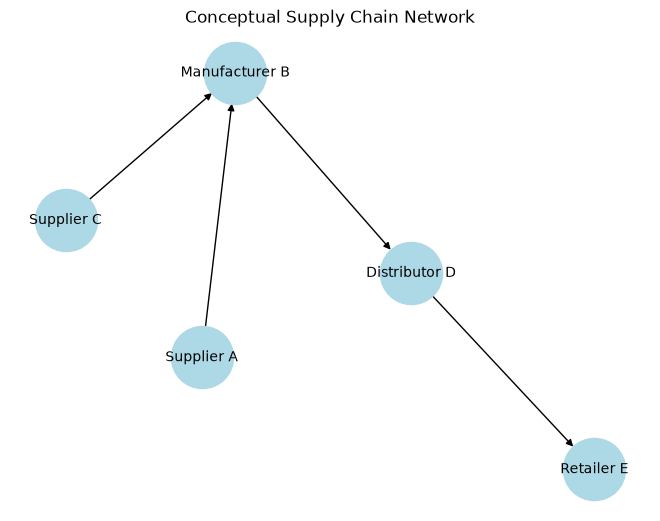

A GNN would take this graph structure and node features as input to learn a model.


In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# Conceptual example of a supply chain graph
G = nx.DiGraph()
G.add_edge('Supplier A', 'Manufacturer B')
G.add_edge('Supplier C', 'Manufacturer B')
G.add_edge('Manufacturer B', 'Distributor D')
G.add_edge('Distributor D', 'Retailer E')

# Visualize the graph
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, arrows=True)
plt.title('Conceptual Supply Chain Network')
plt.show()

print("A GNN would take this graph structure and node features as input to learn a model.")
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
%config InlineBackend.figure_format = 'retina'


### Three-Tier Practice Ladder

**1. Mechanism and assumptions (Conceptual):** Explain the loss/objective and inductive bias of **Chapter 7.19: Graph Neural Networks (GNNs): Learning on Relational Data**. Distinguish optimization error, estimation error, and generalization error in the economic use case.

**2. Reproduce and diagnose (Applied):** Build a leakage-safe validation experiment using 1. Why GNNs? The Importance of Network Data in Economics, 2. The Message Passing Mechanism. Compare a simple baseline with the featured method using an economically relevant metric and report uncertainty across folds or seeds.

**3. Robust extension (Challenge):** Stress-test the model under temporal, subgroup, or covariate distribution shift. Identify which performance degradation matters for the downstream economic decision and propose one mitigation without using the test set for tuning.

**3b. Failure analysis (Challenge):** Message passing changes nothing on a graph of isolated components, and node IDs leak the label through an index feature. Diagnose the graph-construction error and the index leakage, repair the adjacency and drop the leaky feature, and verify with a label-permutation test that accuracy falls to chance.

> Use the existing exercises above when they target the same skill; this ladder makes the intended progression explicit rather than replacing instructor-authored problems.


<a id='exercises'></a>
## 4. Exercises

1.  **GNN for Financial Contagion:** Describe how you would set up a GNN to model financial contagion. What would the nodes represent? What would the edges represent? What node features would be important?

2.  **Message Passing:** In a GNN with two message-passing layers, how many "hops" away can a node receive information from?


<a id='summary'></a>
## 5. Summary and Key Takeaways

Graph Neural Networks (GNNs) operate directly on graph-structured data, using a **message-passing** mechanism to learn from both node features and network structure. They have numerous applications in economics, including the analysis of supply chains, financial networks, and trade flows.


## References & Further Reading

- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
- James, G., Witten, D., Hastie, T., Tibshirani, R. & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
- Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*. MIT Press.
- Kipf, T. N. & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. ICLR 2017.
